# CellChat

In [1]:
# install.packages("Seurat")

# # install.packages("devtools")
# BiocManager::install("BiocNeighbors")
# # devtools::install_github("hadley/devtools")

# install.packages('NMF')
# devtools::install_github("jokergoo/circlize")
# devtools::install_github("jokergoo/ComplexHeatmap")

# devtools::install_github("sqjin/CellChat")

In [2]:
# # in py console
# pip install umap-learn

https://htmlpreview.github.io/?https://github.com/sqjin/CellChat/blob/master/tutorial/CellChat-vignette.html

In [3]:
library(Seurat)
library(ggplot2)
library(dplyr)
library(magrittr)
library(CellChat)              
library(patchwork)
library(igraph)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: igraph


Attaching package: ‘igraph’


The following objects are masked from ‘package:dplyr’:

    as_data_frame, groups, union


The following object is masked from ‘package:Seurat’:

    components


The following objects are masked from ‘package:stats’:

    decompose, spectrum


The following object is masked from ‘package:base’:

    union




In [4]:
# Multicore CPU usage activation - Future

library(future)

plan("multicore", workers = 10) 

options(future.globals.maxSize = 16000 * 1024^2) 

future.seed = NULL 


Attaching package: ‘future’


The following objects are masked from ‘package:igraph’:

    %->%, %<-%




In [5]:
# Load the Seurat obj

Multimodal_seurat_object <- readRDS('Seurat_CellChat.rds')

In [6]:
Idents(Multimodal_seurat_object) <- "CellType"
table(Idents(Multimodal_seurat_object))


             CFU-E             Pro Eb            Baso Eb            Poly Eb 
               440               8940               1878               2089 
          Ortho Eb     ARG1+ Ortho Eb        CD4 T cells        CD8 T cells 
               325                215               2878               1162 
Regulatory T cells            B cells           NK cells          Monocytes 
               274                475               1757               1357 
   Dendritic cells               HSPC 
               120                136 

In [7]:
CellChat <- createCellChat(Multimodal_seurat_object,
#                               group.by = 'Sample',
                              assay = 'SCT',
                              do.sparse = T)

CellChatDB <- CellChatDB.human

CellChatDB.use <- CellChatDB
CellChat@DB <- CellChatDB.use
CellChat <- subsetData(CellChat)
CellChat <- identifyOverExpressedGenes(CellChat)
CellChat <- identifyOverExpressedInteractions(CellChat)

# CellChat <- projectData(CellChat, PPI.mouse)

CellChat <- computeCommunProb(CellChat)

CellChat <- computeCommunProbPathway(CellChat)

CellChat <- aggregateNet(CellChat)

library(NMF)
library(ggalluvial)

[1] "Create a CellChat object from a Seurat object"
The `meta.data` slot in the Seurat object is used as cell meta information 


Warning message in createCellChat(Multimodal_seurat_object, assay = "SCT", do.sparse = T):
“The 'meta' data does not have a column named `samples`. We now add this column and all cells are assumed to belong to `sample1`! 
”


Set cell identities for the new CellChat object 
The cell groups used for CellChat analysis are  CFU-E, Pro Eb, Baso Eb, Poly Eb, Ortho Eb, ARG1+ Ortho Eb, CD4 T cells, CD8 T cells, Regulatory T cells, B cells, NK cells, Monocytes, Dendritic cells, HSPC 
The number of highly variable ligand-receptor pairs used for signaling inference is 31 
triMean is used for calculating the average gene expression per cell group. 
[1] ">>> Run CellChat on sc/snRNA-seq data <<< [2026-08-26 23:16:47.802553]"
[1] ">>> CellChat inference is done. Parameter values are stored in `object@options$parameter` <<< [2026-08-26 23:17:49.232771]"


Loading required package: registry

Loading required package: rngtools

Loading required package: cluster

NMF - BioConductor layer [OK] | Shared memory capabilities [NO: bigmemory] | Cores 2/2

  To enable shared memory capabilities, try: install.extras('
NMF
')


Attaching package: ‘NMF’


The following object is masked from ‘package:future’:

    run


The following object is masked from ‘package:generics’:

    fit


The following objects are masked from ‘package:igraph’:

    algorithm, compare




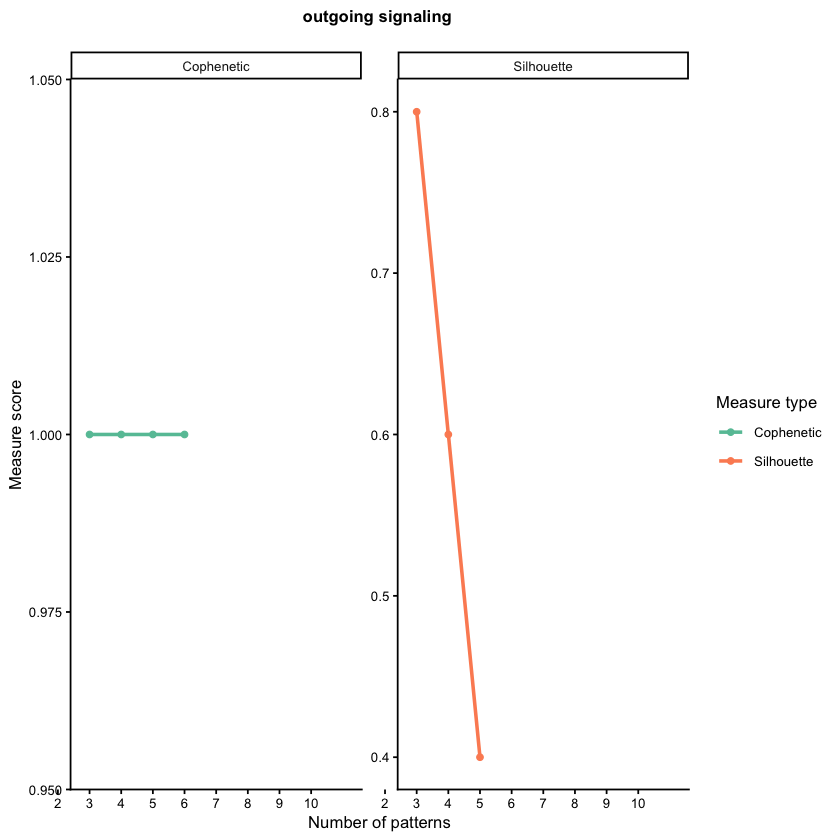

In [8]:
selectK(CellChat, pattern = "outgoing")

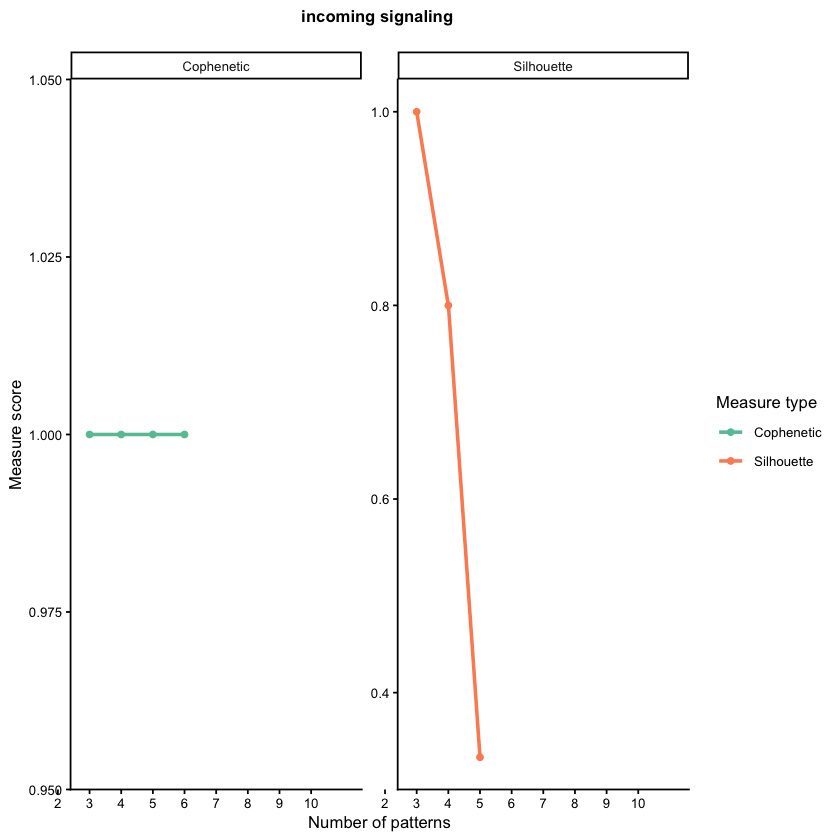

In [9]:
selectK(CellChat, pattern = "incoming")

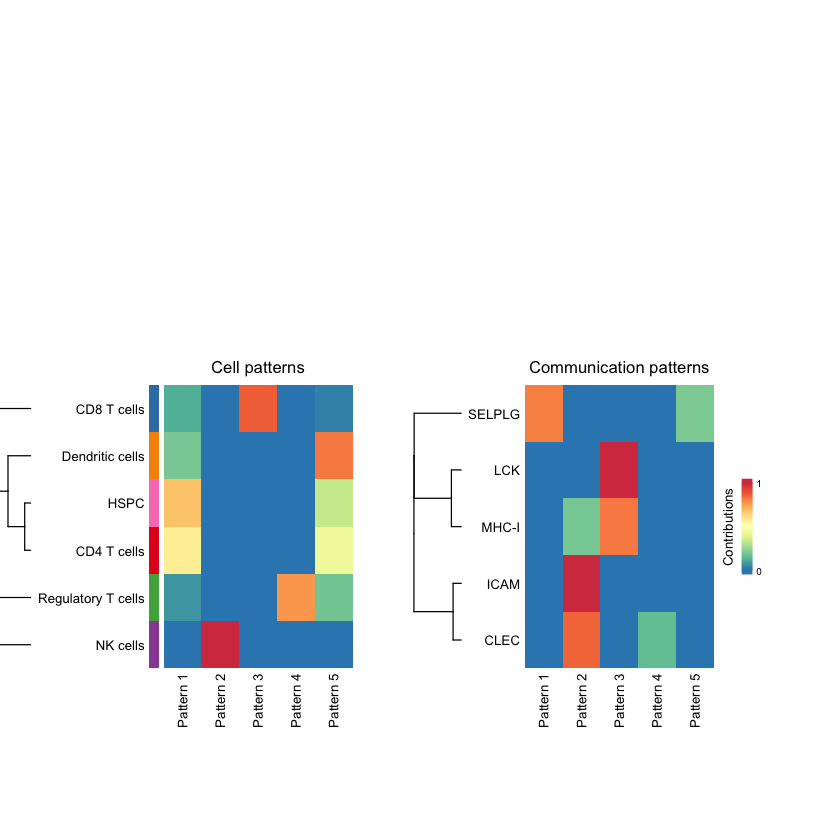

In [10]:
nPatterns = 5
CellChat <- identifyCommunicationPatterns(CellChat, 
                                          pattern = "outgoing", 
                                          k = nPatterns)
nPatterns = 5
CellChat <- identifyCommunicationPatterns(CellChat, 
                                          pattern = "incoming", 
                                          k = nPatterns)

In [11]:
library(ComplexHeatmap)

ht <- netVisual_heatmap(CellChat, measure = "count")

jpeg("Dot_Plot_nComms.jpeg", width = 17, height = 16, units = "cm", res = 600)
draw(ht, heatmap_legend_side = "right",
         annotation_legend_side = "right")
dev.off()

Loading required package: grid

ComplexHeatmap version 2.26.0
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite either one:
- Gu, Z. Complex Heatmap Visualization. iMeta 2022.
- Gu, Z. Complex heatmaps reveal patterns and correlations in multidimensional 
    genomic data. Bioinformatics 2016.


The new InteractiveComplexHeatmap package can directly export static 
complex heatmaps into an interactive Shiny app with zero effort. Have a try!

This message can be suppressed by:
  suppressPackageStartupMessages(library(ComplexHeatmap))


Do heatmap based on a single object 




agg_record_1109319316 
                    2

Please make sure you have load `library(ggalluvial)` when running this function



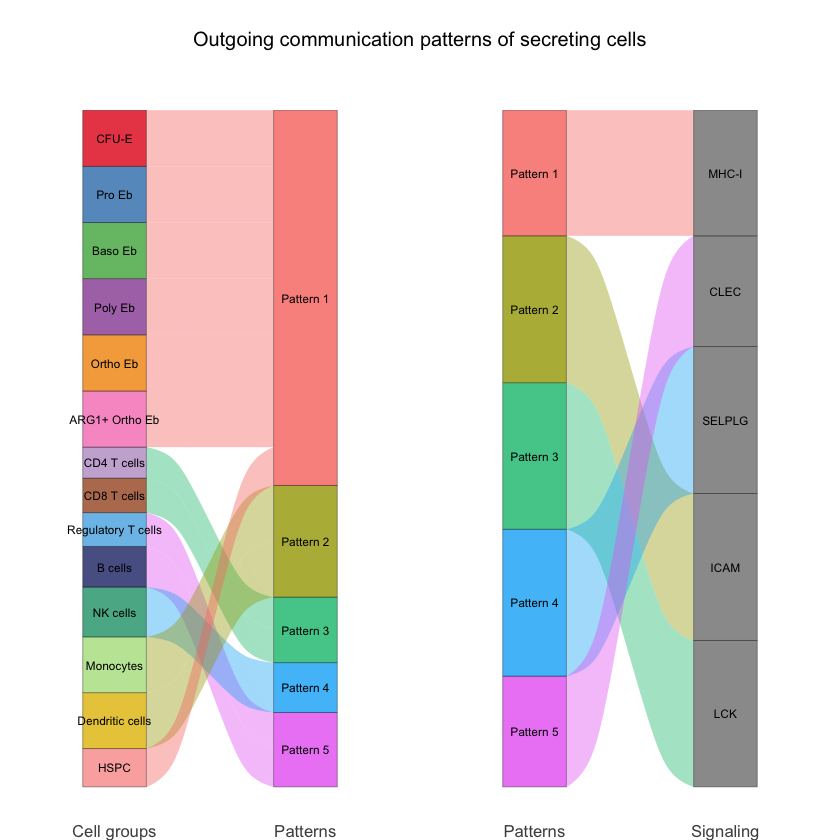

In [12]:
# river plot
netAnalysis_river(CellChat, pattern = "outgoing")
#> Please make sure you have load `library(ggalluvial)` when running this function

In [13]:
# Dot plot of outgoing communications

p <- netAnalysis_dot(CellChat, pattern = "outgoing")

p_flipped <- p & coord_flip()

ggsave(
  "Dot_Plot_Outgoing.jpeg",
  # plot = p,
  plot = p_flipped,
  device = "jpeg",
  width = 14.5,
  height = 28,
  units = "cm",
  dpi = 600,
  limitsize = TRUE
)

In [14]:
# Dot plot of incoming communications

p <- netAnalysis_dot(CellChat, pattern = "incoming")

p_flipped <- p & coord_flip()

ggsave(
  "Dot_Plot_Incoming.jpeg",
  # plot = p,
  plot = p_flipped,
  device = "jpeg",
  width = 14.5,
  height = 28,
  units = "cm",
  dpi = 600,
  limitsize = TRUE
)

In [15]:
# pathways.show <- c("MHC-II")
# vertex.receiver = seq(1, 4)

# jpeg("MHC_II_Circle.jpg", width = 10, height = 10, units = "in", res = 500)
# par(mfrow=c(1,1))
# netVisual_aggregate(CellChat, signaling = pathways.show, layout = "circle")
# dev.off()

In [16]:
CellChat <- netAnalysis_computeCentrality(CellChat, slot.name = "netP")

In [19]:
while (!is.null(dev.list())) dev.off()

w <- 10
h <- 10
f_size <- 12 

# Incoming
jpeg("CellChat_Inc.jpg", width = w, height = h, units = "in", res = 500)
p_in <- netAnalysis_signalingRole_heatmap(CellChat, 
                                          pattern = "incoming", 
                                          width = w, 
                                          height = h, 
                                          font.size = f_size)
print(p_in)
dev.off()

# Outgoing
jpeg("CellChat_Out.jpg", width = w, height = h, units = "in", res = 500)
p_out <- netAnalysis_signalingRole_heatmap(CellChat, 
                                           pattern = "outgoing", 
                                           width = w, 
                                           height = h, 
                                           font.size = f_size)
print(p_out)
dev.off()

pdf 
  2

pdf 
  2